In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
import pandas as pd
import xarray as xr
from sklearn.metrics import mean_squared_error
from math import cos, asin, sqrt, pi

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import re
import ipywidgets as widgets

import sys
sys.path.insert(1, '../Modules/')
from EPE_seasonal_forecast import *

# Step-1 - Select data-driven model

Define simple data-driven forecasting models.

In [2]:
# define the data-driven models to consider
LAS = Lasso(alpha=0.1)

LR = LinearRegression()

RID = Ridge(alpha=10.0)

MLP = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=1e-2,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    max_iter=5000,
    random_state=1
)


SVR_poly = SVR(kernel='poly', C=1, gamma=0.01, epsilon=0.5, degree=3)


SVR_linear = SVR(kernel='linear', C=5, gamma=0.05, epsilon=0.1)

# Step-2 - Extract postprocessed predictors

The following code describes a post-processing approach for the predictors generated by the feature selection algorithm (with 10000 evaluations) at each grid point.

Procedure:

a) Generate 80 clusters of Total Precipitation time
series using the same clustering procedure
applied to the predictors.

b) For each spatial cluster, aggregate the selected
predictors across all grid points within that cluster.

c) Retain only the top 4% of predictors based on their
selection frequency.

d) Use this top 4% subset as the predictor set for
training the data-driven model in all grid points of
that cluster.

In [3]:
# region="Cluj-Napoca"
# lon='''23°33'00"E'''
# lat='''46°46'00"N'''

region = 'Southern-France'
lon='''5°30'0"E'''
lat='''45°30'0"N'''

# region = 'Denmark'
# lon='''9°15'0"E'''
# lat='''56°0'0"N'''

# region = 'Gerona'
# lon='''2°49'0"E'''
# lat='''41°59'0"N'''

# region = 'Bodo'
# lon='''14°22'30.36"E'''
# lat='''67°16'57.72"N'''

# region = 'Notthingam'
# lon='''1°9'4"W'''
# lat='''52°57'22"N'''

# region="Milano"
# lon='''09°11'24"E'''
# lat='''45°28'01"N'''

# region="London"
# lon = '''0°7'39"W'''
# lat = '''51°30'26"N'''



# Converts coords to integer value
deg, minutes, seconds, direction =  re.split('[°\'"]', lat)
latP= (float(deg) + float(minutes)/60 + float(seconds)/(60*60)) * (-1 if direction in ['W', 'S'] else 1)
deg, minutes, seconds, direction =  re.split('[°\'"]',lon)
lonP= (float(deg) + float(minutes)/60 + float(seconds)/(60*60)) * (-1 if direction in ['W', 'S'] else 1)

In [4]:
### Fixed ###
accumulation_time = 3
quantile = 0.90
num_eval=10000

In [5]:
# set variables
k = 80
variable_name = 'TP'
region_cluster = 'EU_crop_k{}'.format(k)
first_year = 1993
last_year = 2016
alpha = 0.05
first_clima_year = 1993
last_clima_year = 2016
threshold_pca = 0.01


centroids_coords_file = '../DATA/centroids_coords_{}_{}_{}_{}_{}_clim_{}_{}_pcs_{}_centroids.npy'.format(variable_name,region_cluster,first_year, last_year,alpha, first_clima_year, last_clima_year,threshold_pca)

# define the path
labels_file_da = '../DATA/labels_{}_{}_{}_{}_{}_clim_{}_{}_pcs_{}_centroids_da.nc'.format(variable_name,region_cluster,first_year, last_year, alpha, first_clima_year, last_clima_year,threshold_pca)

# open files
labels_PCA_da = xr.open_dataarray(labels_file_da)
centroids_coords = np.load(centroids_coords_file)

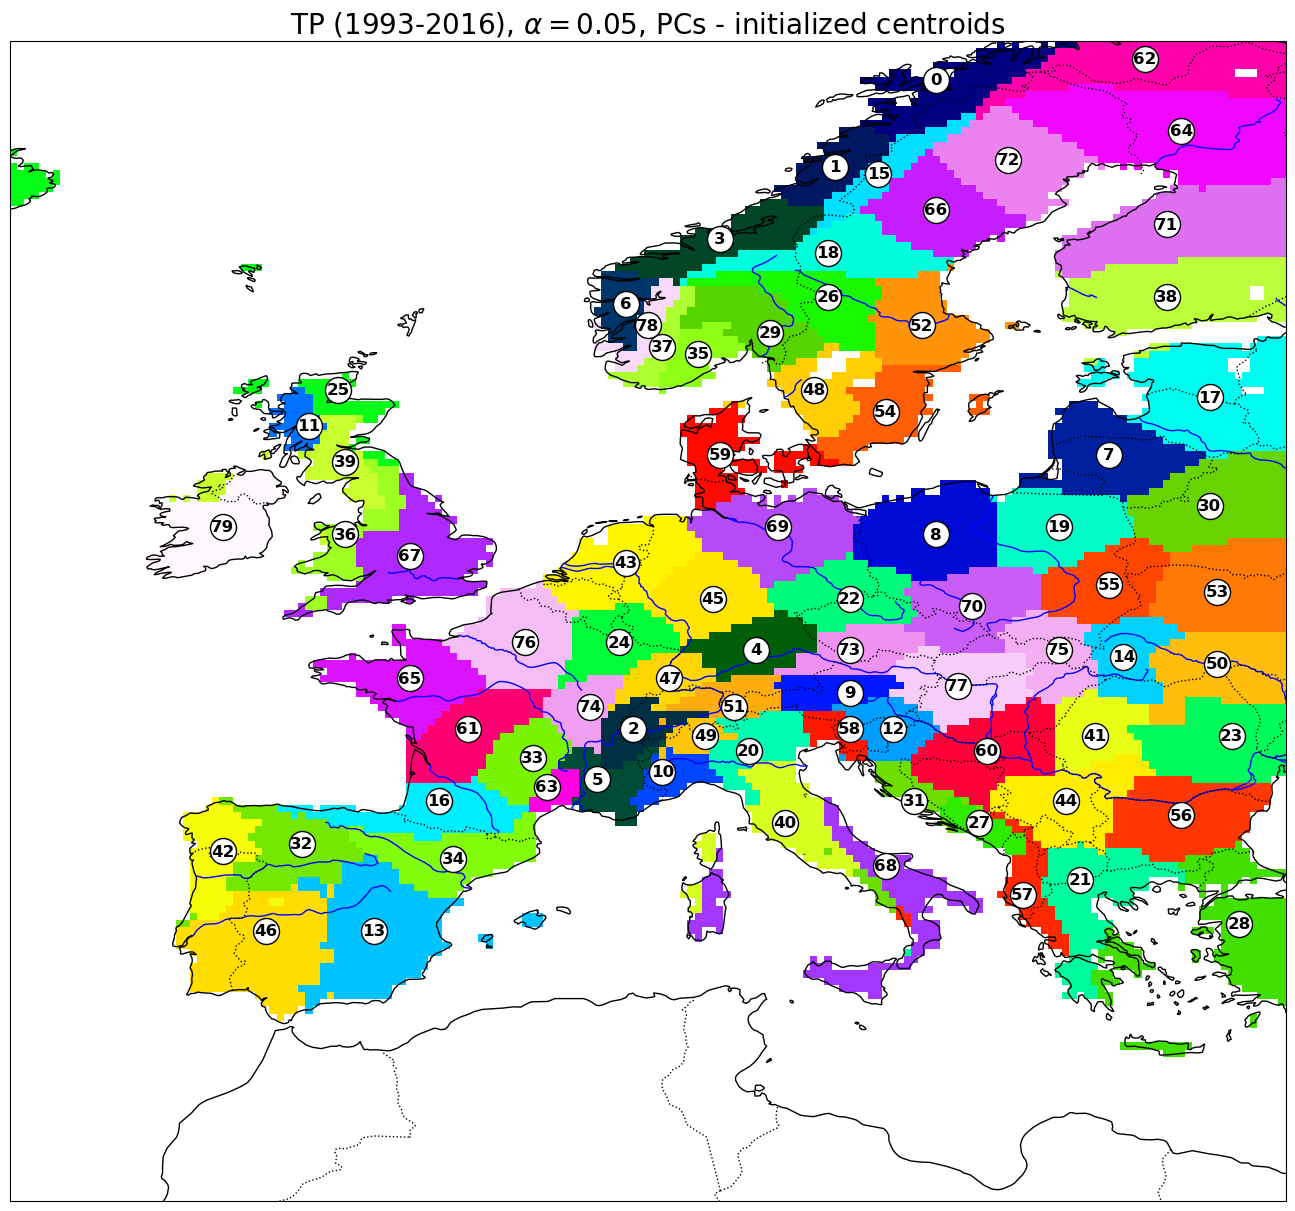

In [6]:
# plot

fig, axi = plt.subplots( figsize=(20, 12), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)#NorthPolarStereo#PlateCarree

n_bins = k  # adjust as needed
bounds = np.linspace(0, k, n_bins+1)  # covers your vmin=-1 to vmax=1
cmap = plt.get_cmap("gist_ncar", n_bins+1)  # discrete version of seismic
norm = BoundaryNorm(bounds, cmap.N)

img = (labels_PCA_da.where((labels_PCA_da.longitude <=29), drop=True).sortby(["latitude", "longitude"])).plot(ax=axi, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False, vmin=0, vmax=k)
axi.coastlines()
#axi.scatter(centroids_coords[:,0], centroids_coords[:,1], marker='x',linewidth=4, s=300,color='black', transform=ccrs.PlateCarree())
axi.set_title("{} ({}-{}), $\\alpha={}$, PCs - initialized centroids".format(variable_name, first_year,last_year, alpha), fontsize=20)

for i, (lon, lat) in enumerate(centroids_coords):
    # optional small marker under the label
    axi.scatter(lon, lat, s=350, color='white', edgecolor='black', transform=ccrs.PlateCarree(), zorder=3)
    axi.text(lon, lat, str(i), transform=ccrs.PlateCarree(),
             fontsize=12, fontweight='bold', color='black',
             ha='center', va='center', zorder=4)

axi.add_feature(cfeature.RIVERS, edgecolor="blue")
# Add country borders
axi.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black")


# Show the plot
#
plt.show()

In [7]:
# open the file containing the predictors for each cluster
best_sol_cluster_matrix = np.load('../DATA/best_sol_cluster_matrix_EU_90.0q_{}_init2_ts5_ac3_k80_top4.npy'.format( num_eval))

In [8]:
# define the cluster index for the location point
cluster_indexP = int(labels_PCA_da.sel(latitude=latP, longitude=lonP, method='nearest').values)
print('Corresponding cluster: ',cluster_indexP)

# select the associated cluster predictors
sols_best = best_sol_cluster_matrix[cluster_indexP, :]

Corresponding cluster:  2


In [9]:
# open predictors file
pred_dataframe = pd.read_csv('../DATA/Predictors_dataset_ERA5_weekly_1940_2024_kmean_1993_2016_0.05_clim_1993_2016_pcs_0.01_centroids_id5_AMJ.csv', index_col=0)

# Step-3 - Open Target Dataset
Open the target time series generated in the previous notebook.

In [10]:
# open the file
target_dataset = pd.read_csv(f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv", index_col='pred_date')

In [11]:
# define the training period
first_train = "1941-03-17"
last_train = "2010-03-17" 

# array of groun truth
gt_train=target_dataset['Target'][first_train:last_train][:-1]
Y_test=target_dataset['Target'][last_train:]

# Step-5 - Visualisation

Inspect the model performance in terms of Root Mean Square Error (RMSE) and Temporal Correlation Coefficient ($\rho$).

Ridge
Lasso
SVR (linear)
multi-layer perceptron
SVR (polynomial)


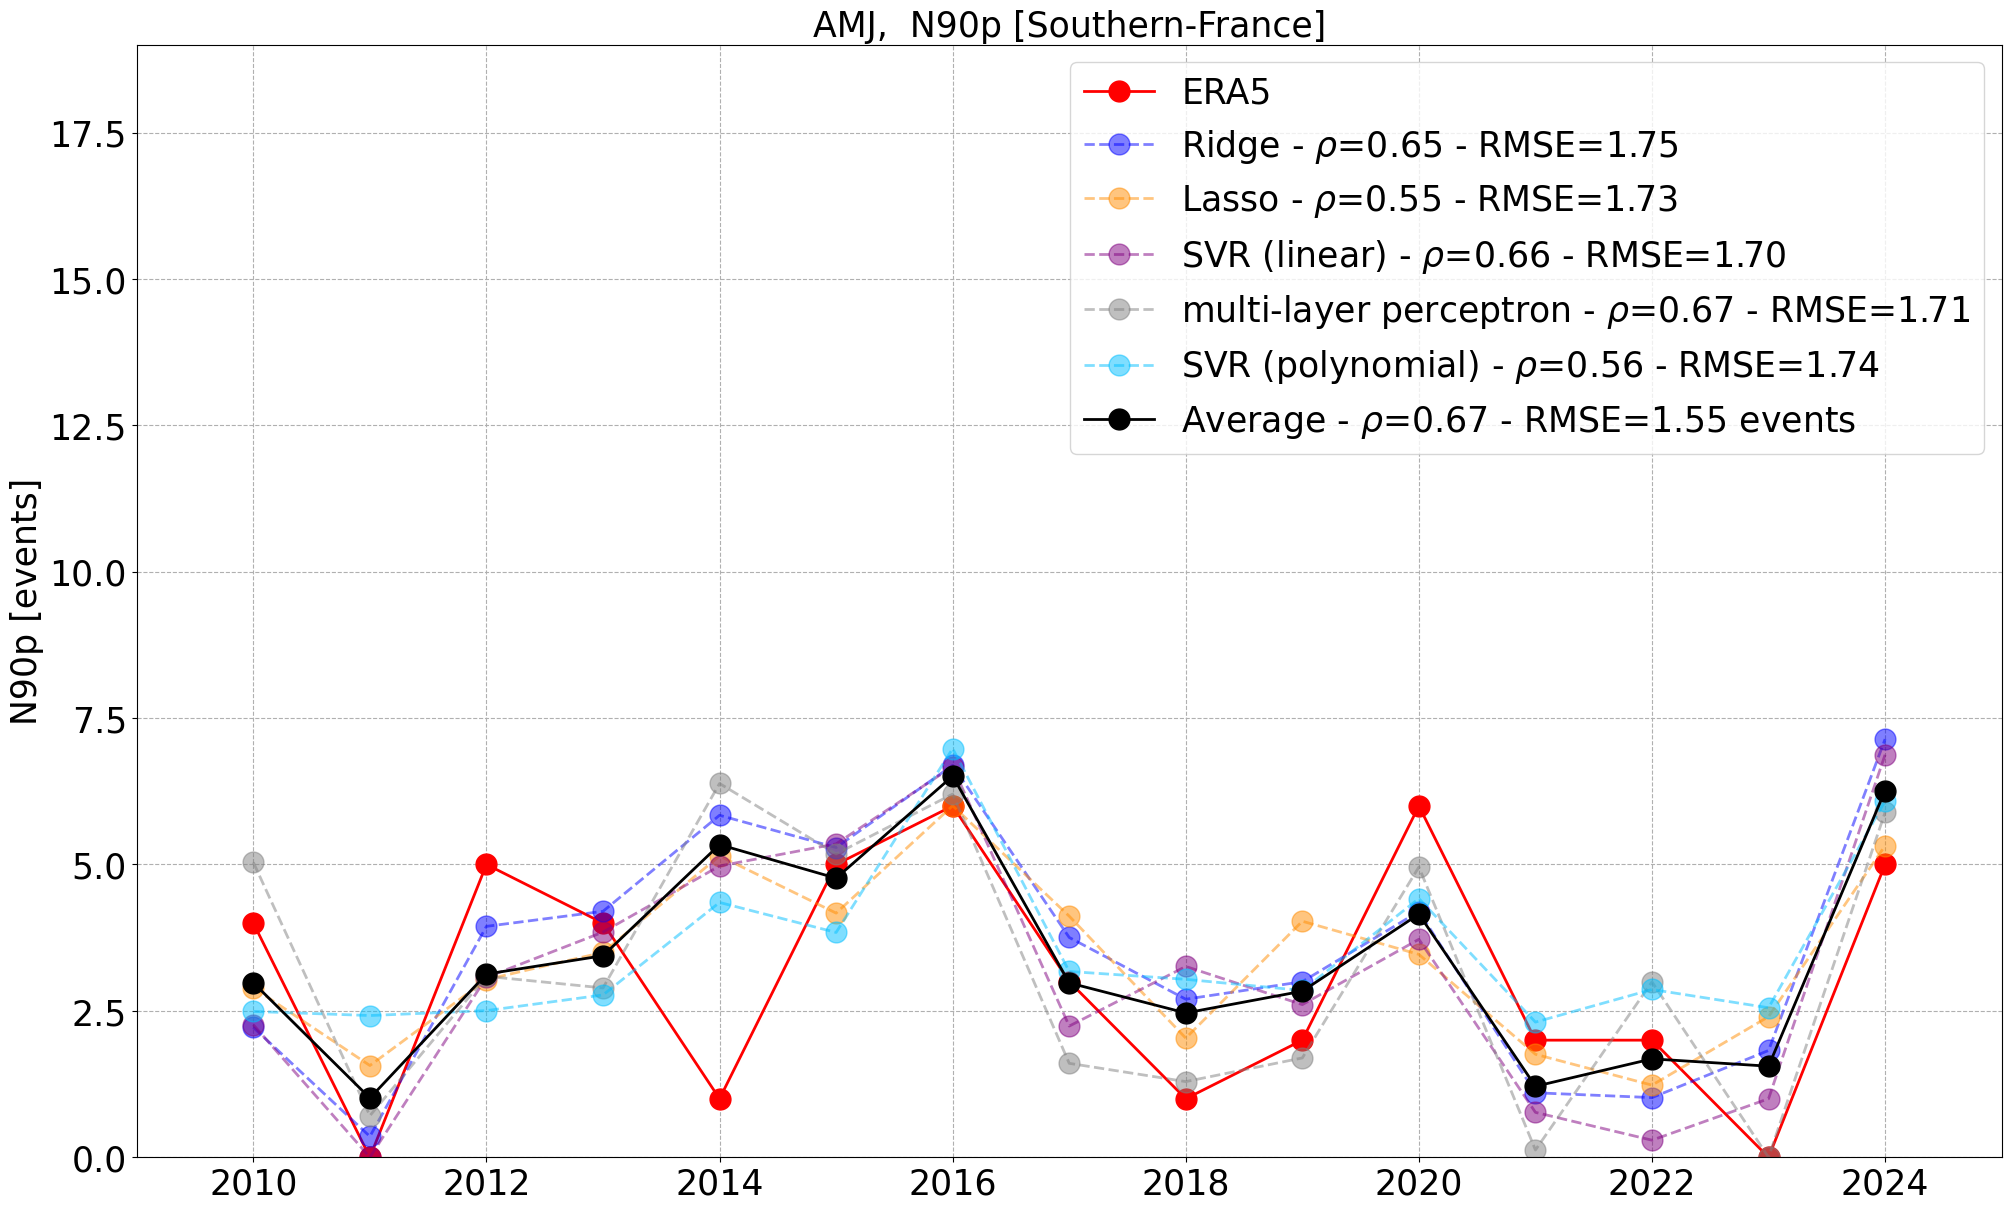

In [12]:
# plot
fig, ax = plt.subplots(figsize=(20, 12), constrained_layout=True)

init = 2
time_step = 5


Y_pred_avg = pd.DataFrame(data = np.zeros((len(Y_test.index))), index=Y_test.index, columns=['Y_pred'])

ax.plot(
    pd.to_datetime(Y_test.index[init::time_step]).year,
    Y_test[init::time_step],
    c='red',marker='o', ms = 15, label=f'ERA5',
    #label=f'Target ({dataset_NQp})',
    linewidth=2)

dd_model_list = [RID, LAS, SVR_linear, MLP, SVR_poly]#, XGB]
dd_model_list_name = ['Ridge', 'Lasso', 'SVR (linear)', 'multi-layer perceptron',  'SVR (polynomial)']#,'XGBoost']
color_list = ['blue', 'darkorange', 'purple', 'gray', 'deepskyblue']#,'limegreen']


for i in range(len(dd_model_list)):

    dd_model_plot = dd_model_list_name[i]
    dd_model = dd_model_list[i]
    color = color_list[i]
    print(dd_model_plot)

    # prediction
    preds = forecast(target_dataset, first_train, last_train, sols_best, dd_model, pred_dataframe)  
    
    # array of groun truth
    Y_test=target_dataset['Target'][last_train:]



    # set values <0 to 0
    Y_pred = pd.DataFrame(np.where(preds[1]<0,0,preds[1]), columns=['Y_pred'], index=Y_test.index)

    # convert to pd df
    Y_test = pd.DataFrame(Y_test.values, columns=['Y_test'], index=Y_test.index)
    
    Y_pred_avg = Y_pred_avg + Y_pred

    rmse_forecast_dd_model = np.sqrt(mean_squared_error(Y_test[init::time_step],Y_pred[init::time_step]))
    corr_dd_model=sp.pearsonr(Y_test[init::time_step],Y_pred[init::time_step])

    ax.plot(
    pd.to_datetime(Y_pred.index[init::time_step]).year,
    Y_pred[init::time_step],
    color = color, marker='o', ms=15,
    # color='tab:green',
    label='{} - $\\rho$={:.2f} - RMSE={:.2f}'.format(dd_model_plot, corr_dd_model.statistic[0], rmse_forecast_dd_model),
    # linestyle='go-',
    linewidth=2, alpha = 0.5, ls='--'
    )

rmse_forecast_avg  = np.sqrt(mean_squared_error(Y_test[init::time_step],Y_pred_avg[init::time_step]/len(dd_model_list)))
corr_avg =sp.pearsonr(Y_test[init::time_step],Y_pred_avg[init::time_step]/len(dd_model_list))

ax.plot(
pd.to_datetime(Y_pred_avg.index[init::time_step]).year,
Y_pred_avg[init::time_step]/len(dd_model_list),
color = 'black', marker='o', ms=15,
# color='tab:green',
label='{} - $\\rho$={:.2f} - RMSE={:.2f} events'.format('Average', corr_avg.statistic[0], rmse_forecast_avg),
# linestyle='go-',
linewidth=2, alpha = 1, ls='-'
)


ax.legend(loc='upper right', fontsize=25)
ax.set_xlabel('', fontsize=25)
ax.set_ylabel('N{}p [events]'.format(int(quantile*100)), fontsize=25)
ax.set_ylim(0,19)
ax.set_xlim(2009,2025)
ax.tick_params(axis='y', labelsize=25) 
ax.tick_params(axis='x', labelsize=25) 
ax.set_title('AMJ,  N{}p [{}]'.format(int(quantile*100), region), fontsize=25)

ax.grid(ls='--')
#plt.savefig(path+'figures/forecast_AMJ_{}_{}_at{}_{}{}.png'.format(region, period, accumulation_time, num_eval, sel_iter))

# Show the plot
plt.show()

 Which is the best one?